In [11]:
import os

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from results_utils import load_results, aggregate_results

sns.set_theme(style="whitegrid")

GRAPHS = ["Erdos50", "Erdos100"]
GEOM_BASE = "../results/boundary_tracking_erdos_geometry"
PDF_DIR = "PDFs"
os.makedirs(PDF_DIR, exist_ok=True)

# label -> (filename stem, color, drop_first)
# drop_first trims CBO's extra leading Best_Y point (Best_Y only; Per_trial_Y is aligned)
METHODS = {
    "CBO-U": ("cbo_unknown_dr2_results", "red", False),
    "CBO": ("cbo_results", "black", True),
    "Random": ("cbo_results_random", "green", False),
}


def curve(results, experiment, drop_first=False):
    mean, std = aggregate_results(results, experiment)
    if drop_first and experiment == "Best_Y":
        mean, std = mean[1:], std[1:]
    return mean, std


def geom_source(graph, nonlinear):
    ns = "_nonlinear" if nonlinear else ""
    folder = f"{graph}_nonlinear" if nonlinear else graph
    return f"{GEOM_BASE}/{folder}", rf".*_cbo_unknown_dr2_boundary_EI_200_2{ns}.pickle"


def method_regex(stem, nonlinear):
    ns = "_nonlinear" if nonlinear else ""
    return rf".*_{stem}_200_2{ns}.pickle"


def _plot_on_ax(ax, graph, experiment, nonlinear):
    gbase, gregex = geom_source(graph, nonlinear)
    mean, std = curve(load_results(gbase, gregex), experiment)
    x = range(len(mean))
    ax.fill_between(x, mean - std, mean + std, alpha=0.2, color="purple")
    ax.plot(x, mean, label="CBO-U-Geo", color="purple", linewidth=2)

    for label, (stem, color, drop_first) in METHODS.items():
        mean, std = curve(load_results(f"../results/{graph}", method_regex(stem, nonlinear)),
                          experiment, drop_first)
        x = range(len(mean))
        ax.fill_between(x, mean - std, mean + std, alpha=0.2, color=color)
        ax.plot(x, mean, label=label, color=color, linewidth=2)

    ax.set_xlabel("Trial")
    ax.set_ylabel(experiment)
    ax.grid(True)
    ax.legend()


def _show(fig, pdf_name):
    fig.tight_layout()
    fig.savefig(f"{PDF_DIR}/{pdf_name}.pdf", bbox_inches="tight")
    display(fig)
    plt.close(fig)


def plot_experiment(experiment, nonlinear=False):
    kind = "nonlinear" if nonlinear else "linear"
    fig, axes = plt.subplots(1, len(GRAPHS), figsize=(14, 5))
    for ax, graph in zip(axes, GRAPHS):
        _plot_on_ax(ax, graph, experiment, nonlinear)
        ax.set_title(f"{graph} ({kind})")
    _show(fig, f"{experiment}_{kind}")


def plot_graph_stacked(graph, nonlinear=False):
    kind = "nonlinear" if nonlinear else "linear"
    fig, axes = plt.subplots(2, 1, figsize=(8, 10))
    for ax, experiment in zip(axes, ["Best_Y", "Per_trial_Y"]):
        _plot_on_ax(ax, graph, experiment, nonlinear)
        ax.set_title(f"{graph} ({kind}) - {experiment}")
    _show(fig, f"{graph}_{kind}")

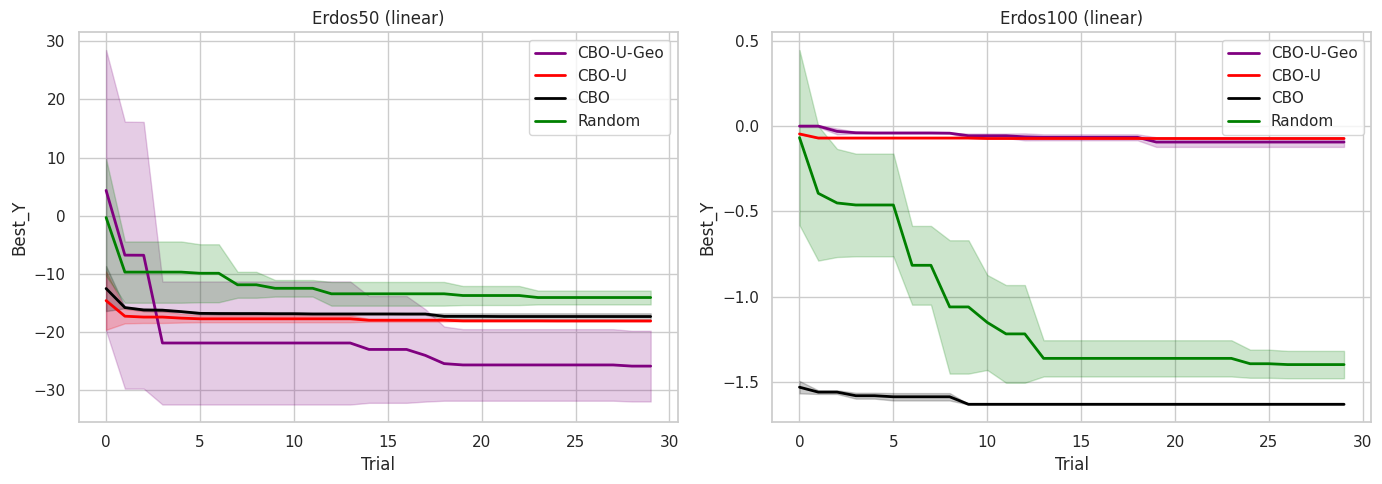

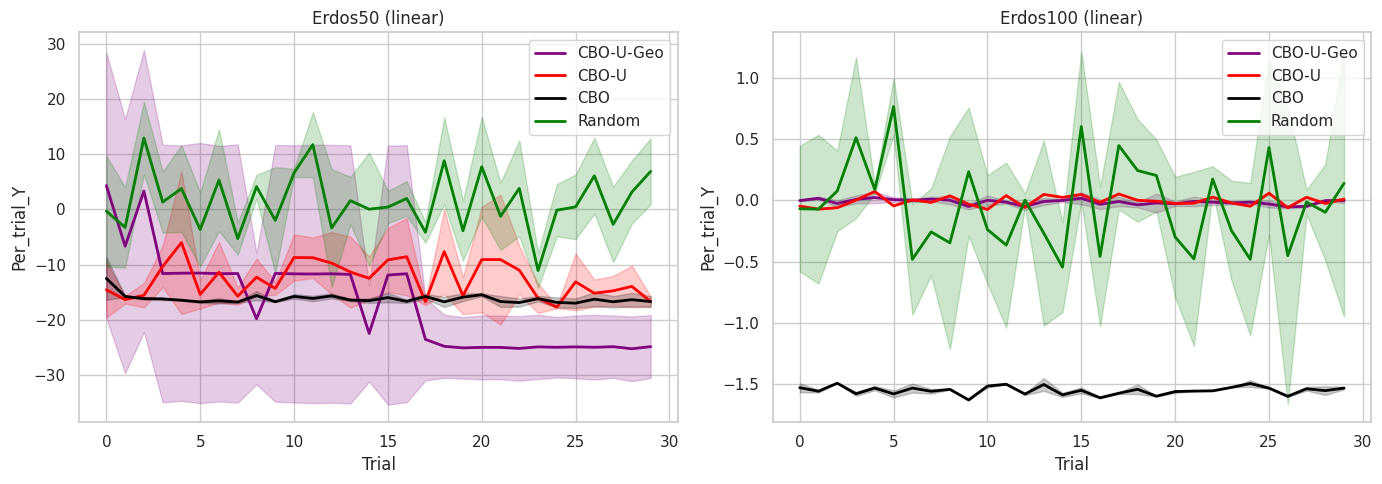

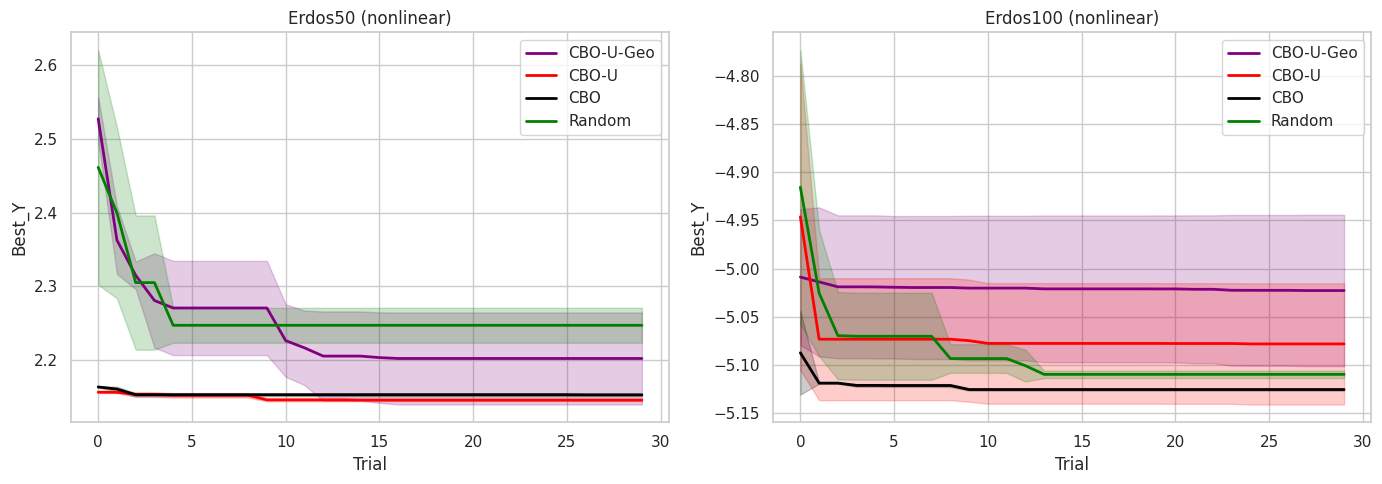

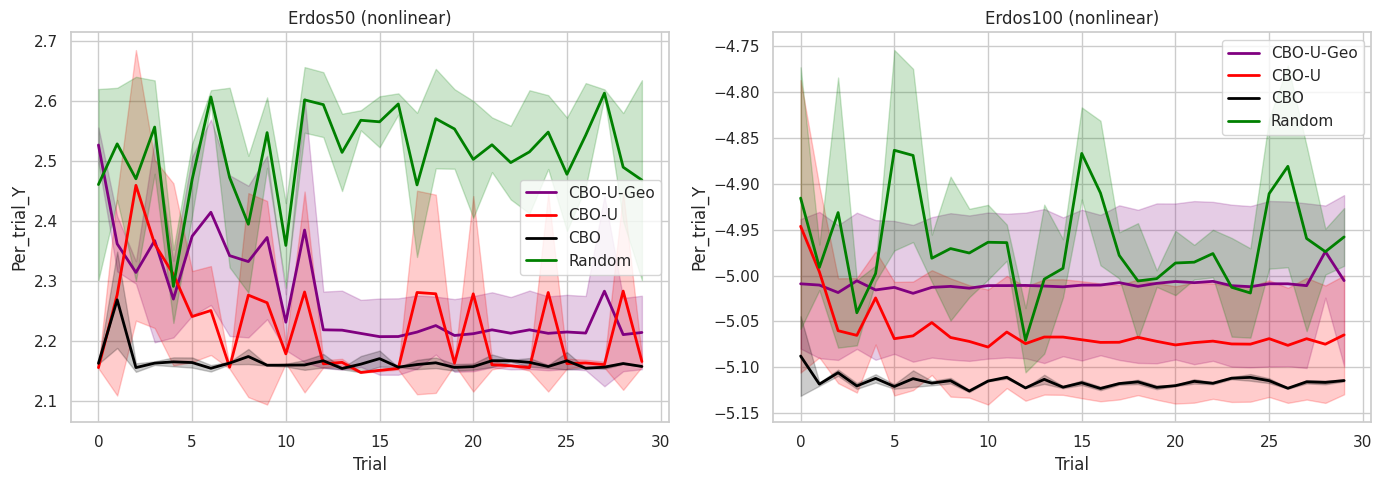

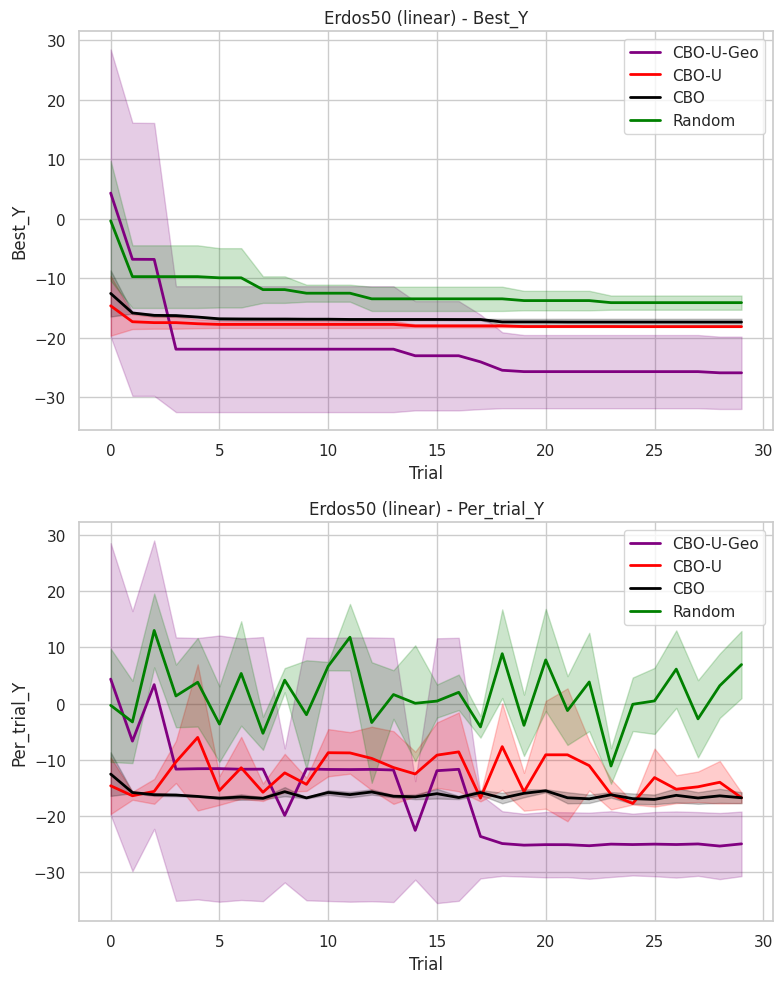

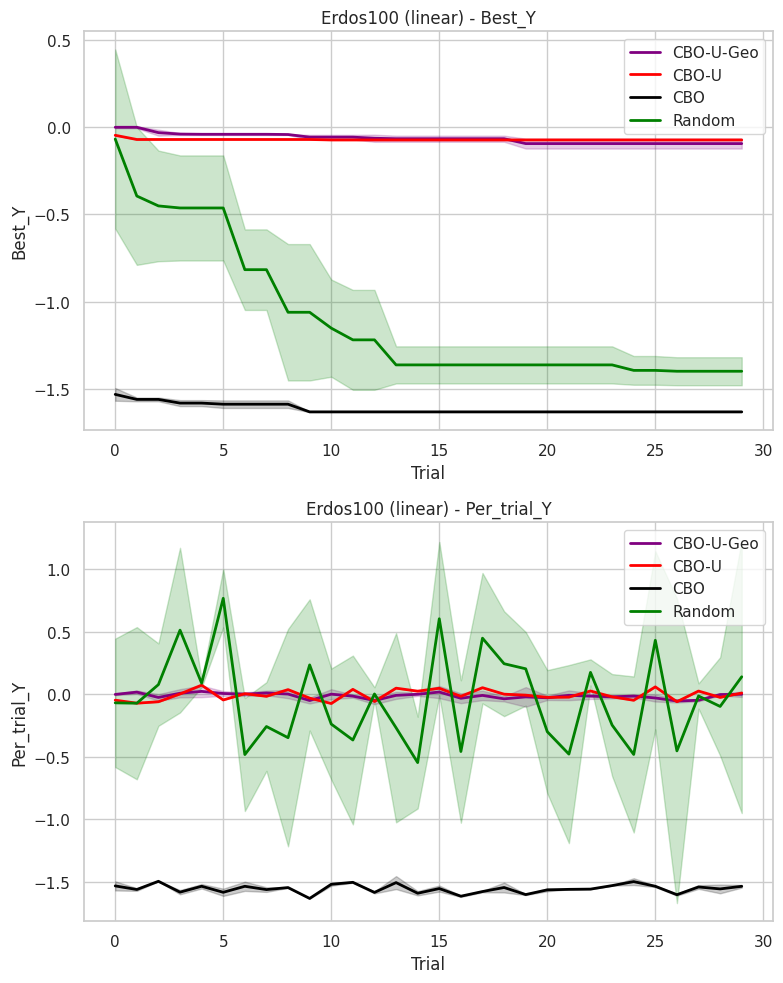

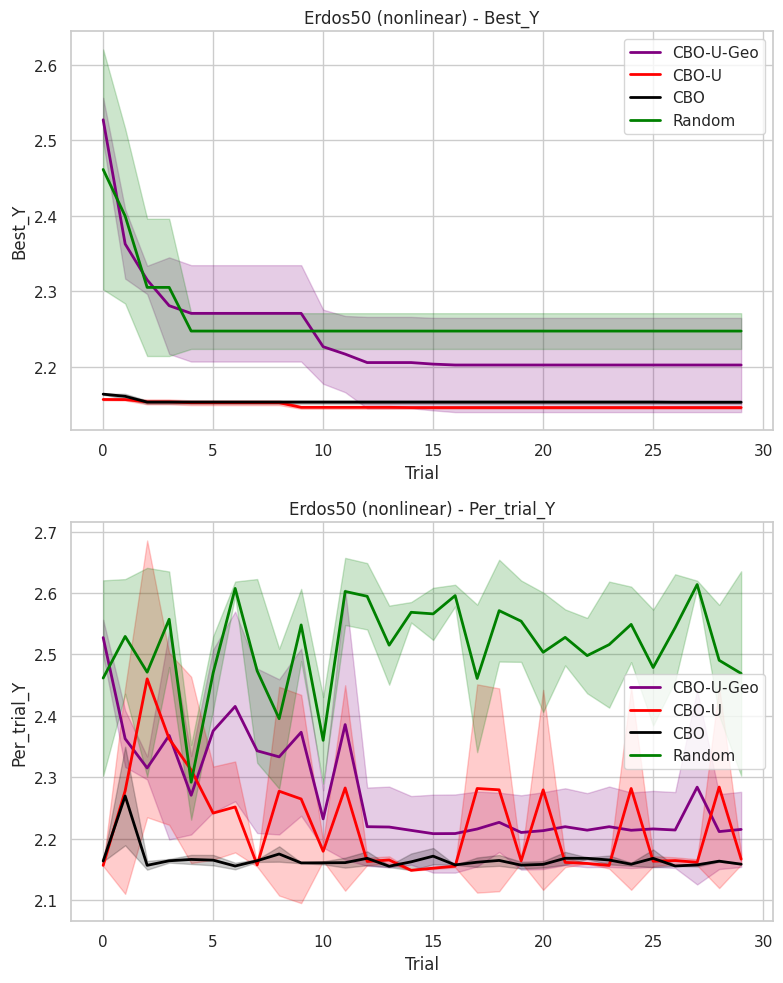

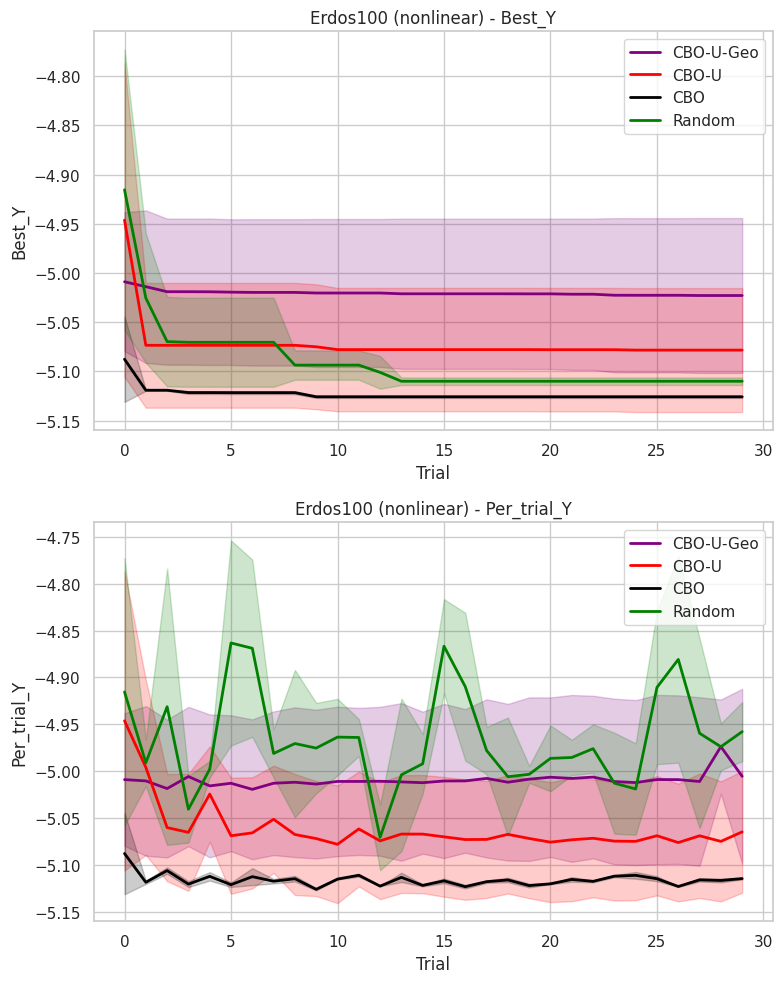

In [12]:
# Comparison figures (Erdos50 + Erdos100 side by side) -> PDFs/<experiment>_<kind>.pdf
plot_experiment("Best_Y")
plot_experiment("Per_trial_Y")
plot_experiment("Best_Y", nonlinear=True)
plot_experiment("Per_trial_Y", nonlinear=True)

# Per-graph PDFs: Best_Y over Per_trial_Y -> PDFs/<graph>_<kind>.pdf
for nonlinear in [False, True]:
    for graph in GRAPHS:
        plot_graph_stacked(graph, nonlinear)

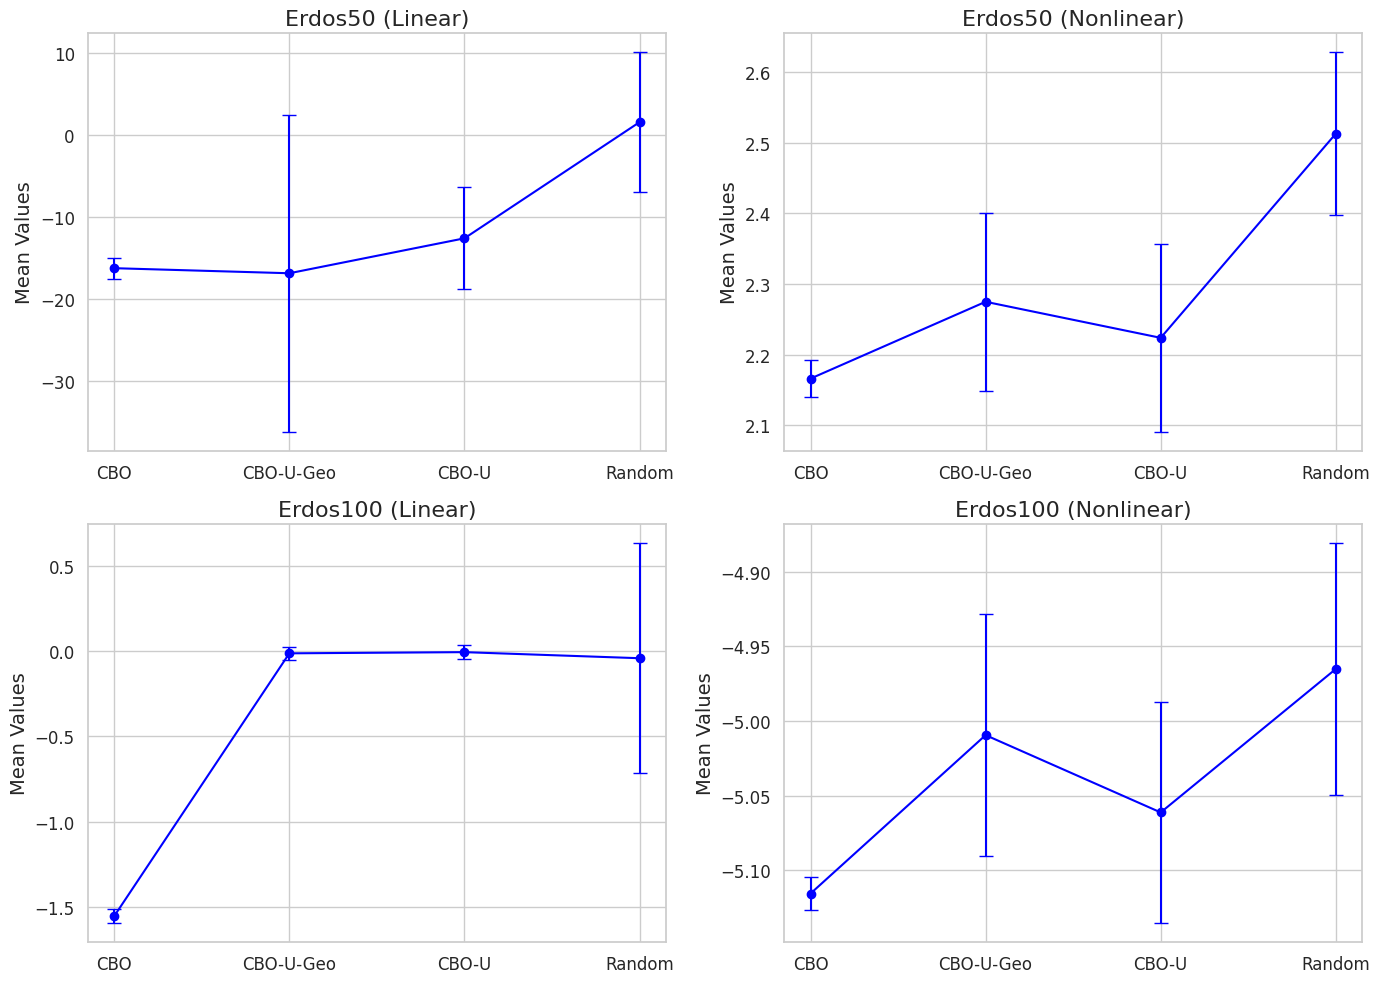

In [13]:
import os

# mean value = mean of Per_trial_Y pooled across all runs/trials (as all_means does)
def mean_value(base, regex):
    if not os.path.isdir(base):
        return np.nan, 0.0
    results = load_results(base, regex)
    if not results:
        return np.nan, 0.0
    pooled = np.hstack([r["Per_trial_Y"] for r in results])
    return pooled.mean(), pooled.std()


def summarise():
    method_labels = ["CBO", "CBO-U-Geo", "CBO-U", "Random"]
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    for r, graph in enumerate(GRAPHS):
        for c, nonlinear in enumerate([False, True]):
            ns = "_nonlinear" if nonlinear else ""
            specs = [
                (f"../results/{graph}", rf".*_cbo_results_200_2{ns}.pickle"),
                (f"{GEOM_BASE}/{graph}{ns}", rf".*_cbo_unknown_dr2_boundary_EI_200_2{ns}.pickle"),
                (f"../results/{graph}", rf".*_cbo_unknown_dr2_results_200_2{ns}.pickle"),
                (f"../results/{graph}", rf".*_cbo_results_random_200_2{ns}.pickle"),
            ]
            means, stds = zip(*[mean_value(b, rx) for b, rx in specs])
            ax = axs[r, c]
            ax.errorbar(method_labels, means, yerr=stds, marker="o", capsize=5,
                        linestyle="-", color="blue")
            ax.tick_params(axis="both", labelsize=12)
            ax.set_title(f"{graph} ({'Nonlinear' if nonlinear else 'Linear'})", fontsize=16)
            ax.set_ylabel("Mean Values", fontsize=14)
    _show(fig, "mean_summary")


summarise()

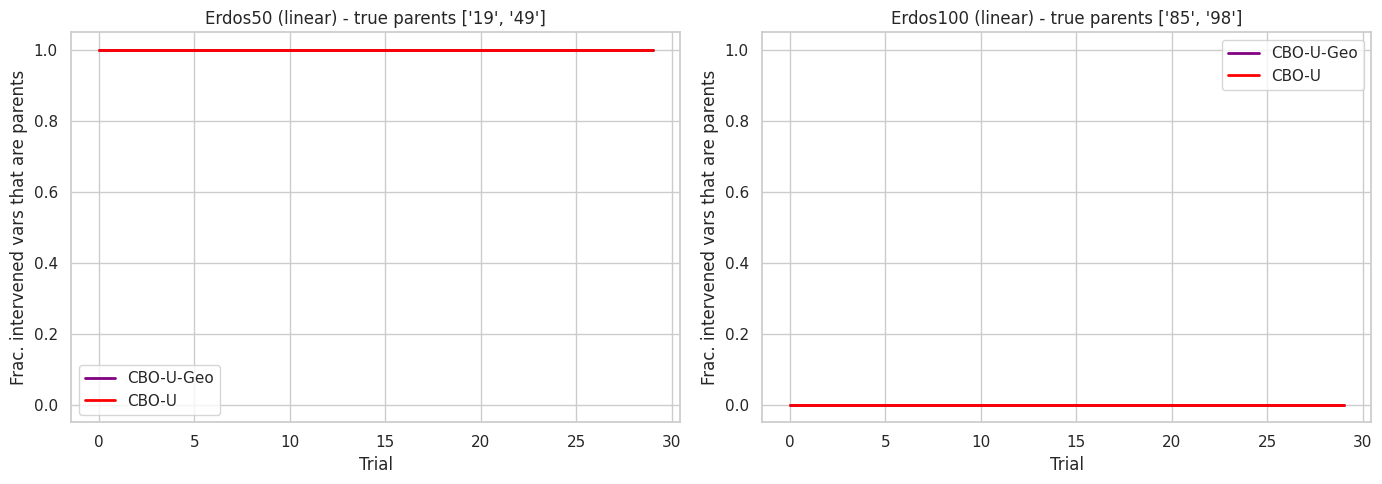

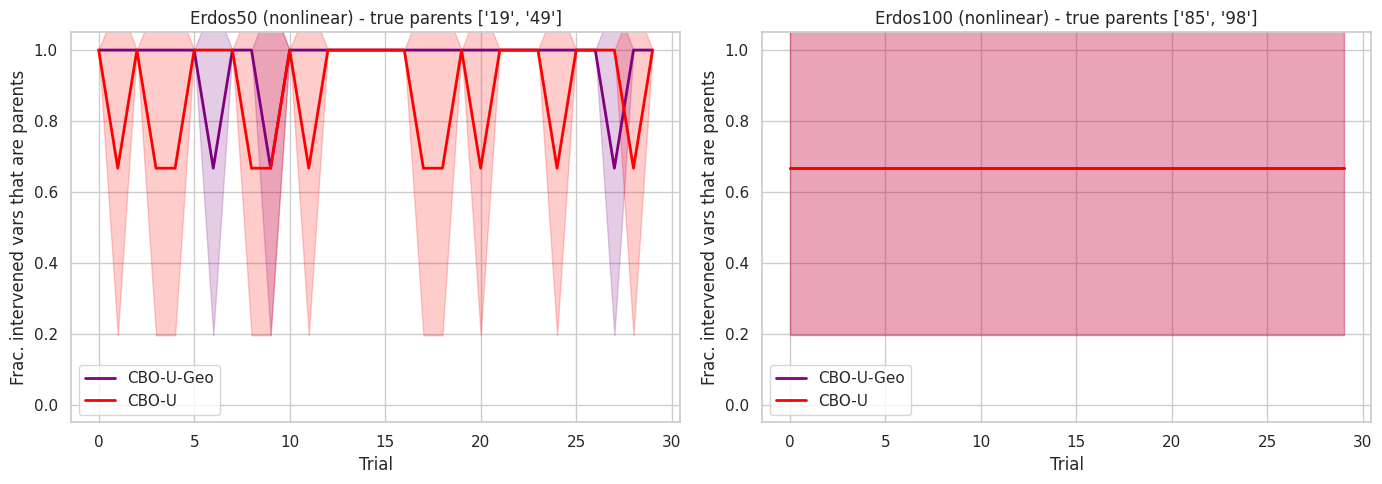

In [14]:
# Parent accuracy per iteration: fraction of the intervened variables that are
# true parents of the target. Compare CBO-U vs CBO-U-Geo, per erdos graph.
# True parents come from the geometry pickle (CBO-U pickles don't store them);
# both pipelines share the same fixed ErdosRenyi structure (seed=17).

def true_parents_for(graph, nonlinear=False):
    gbase, gregex = geom_source(graph, nonlinear)
    return set(load_results(gbase, gregex)[0]["True_Parents"])


def parent_accuracy(results, true_parents):
    curves = []
    for r in results:
        row = []
        for iv in r["Intervention_Set"]:
            iv = tuple(iv)
            row.append(np.nan if len(iv) == 0
                       else sum(v in true_parents for v in iv) / len(iv))
        curves.append(row)
    return np.array(curves, dtype=float)


def plot_parent_accuracy(nonlinear=False):
    kind = "nonlinear" if nonlinear else "linear"
    fig, axes = plt.subplots(1, len(GRAPHS), figsize=(14, 5))
    for ax, graph in zip(axes, GRAPHS):
        tp = true_parents_for(graph, nonlinear)
        gbase, gregex = geom_source(graph, nonlinear)
        sources = {
            "CBO-U-Geo": (load_results(gbase, gregex), "purple"),
            "CBO-U": (load_results(f"../results/{graph}",
                                   method_regex("cbo_unknown_dr2_results", nonlinear)), "red"),
        }
        for label, (res, color) in sources.items():
            acc = parent_accuracy(res, tp)
            mean, std = np.nanmean(acc, axis=0), np.nanstd(acc, axis=0)
            x = range(len(mean))
            ax.fill_between(x, mean - std, mean + std, alpha=0.2, color=color)
            ax.plot(x, mean, label=label, color=color, linewidth=2)
        ax.set_title(f"{graph} ({kind}) - true parents {sorted(tp, key=int)}")
        ax.set_xlabel("Trial")
        ax.set_ylabel("Frac. intervened vars that are parents")
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True)
        ax.legend()
    _show(fig, f"parent_accuracy_{kind}")


plot_parent_accuracy()
plot_parent_accuracy(nonlinear=True)

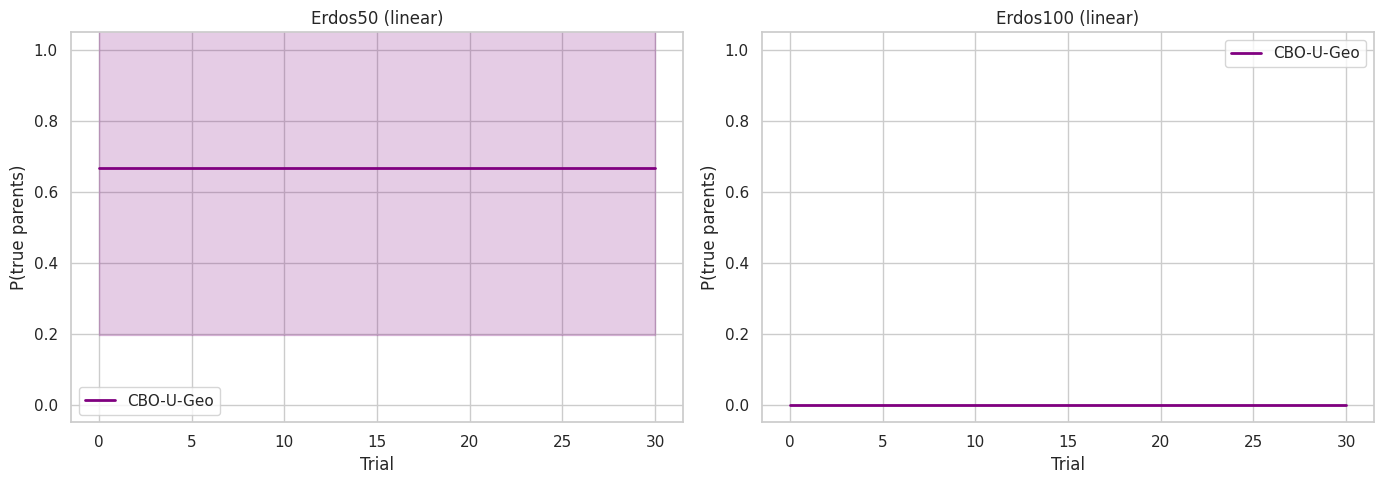

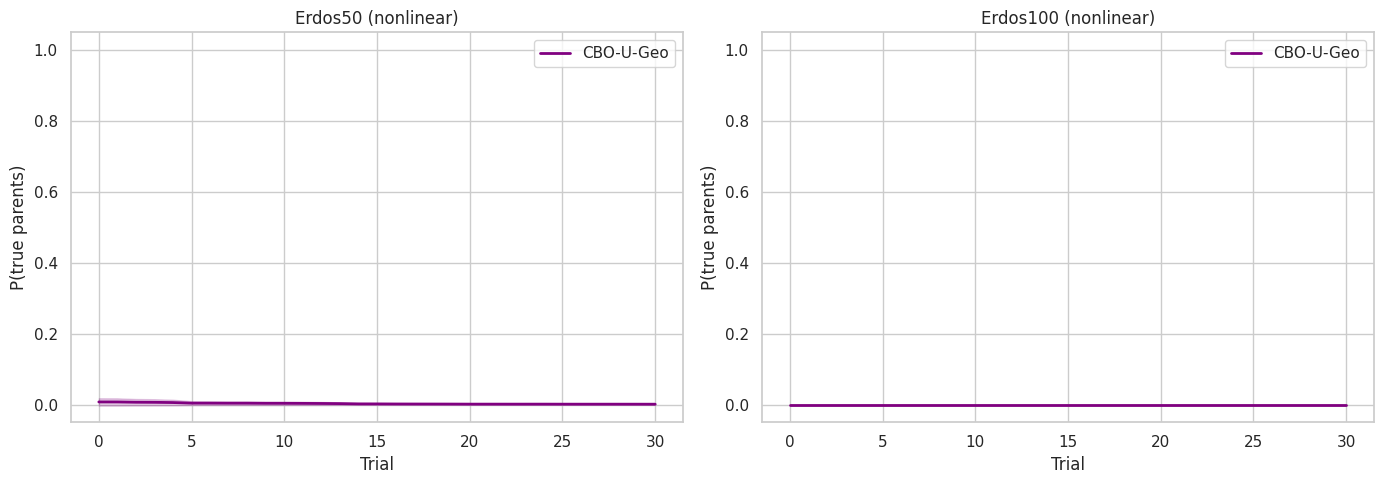

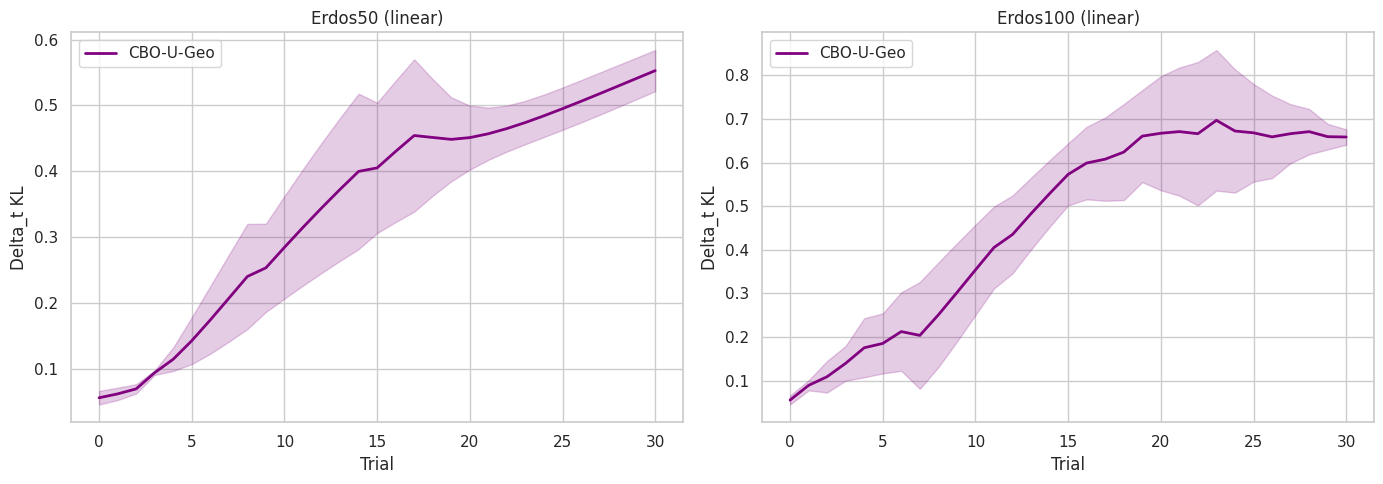

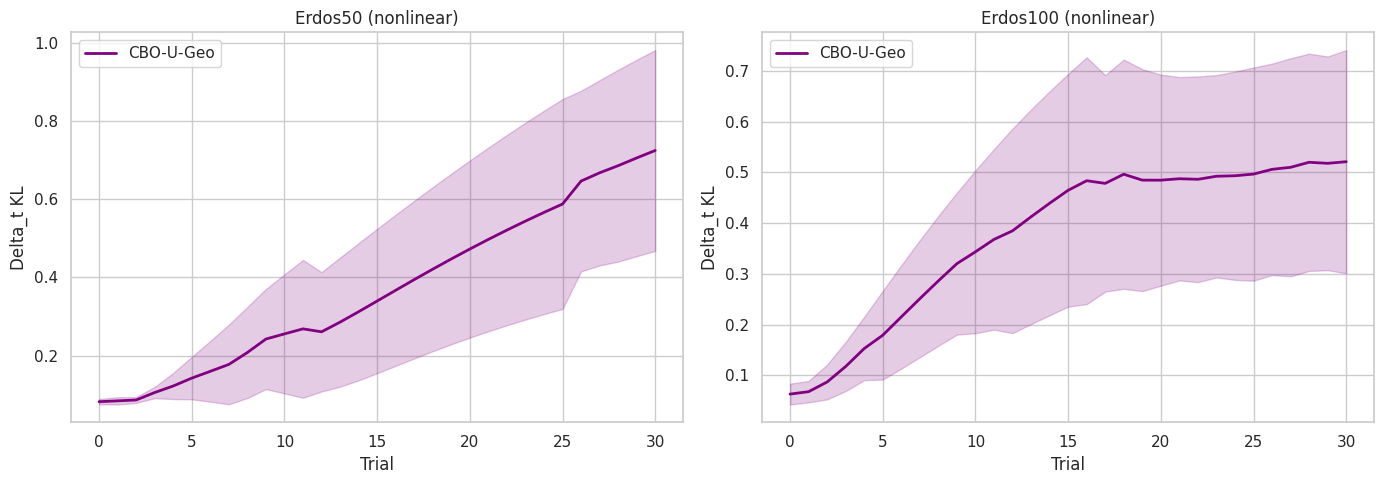

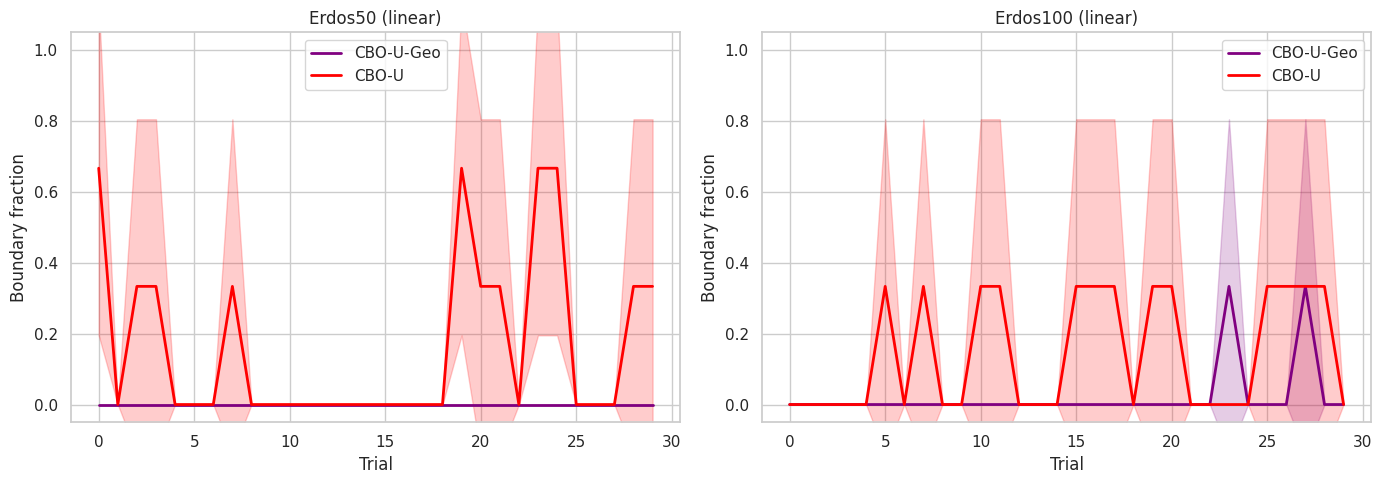

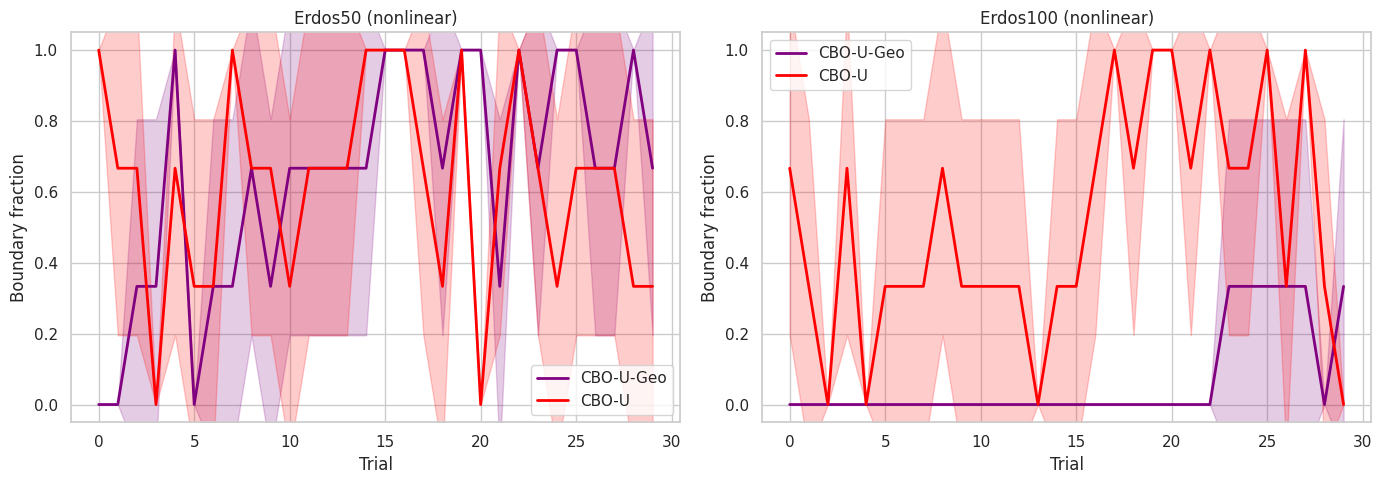

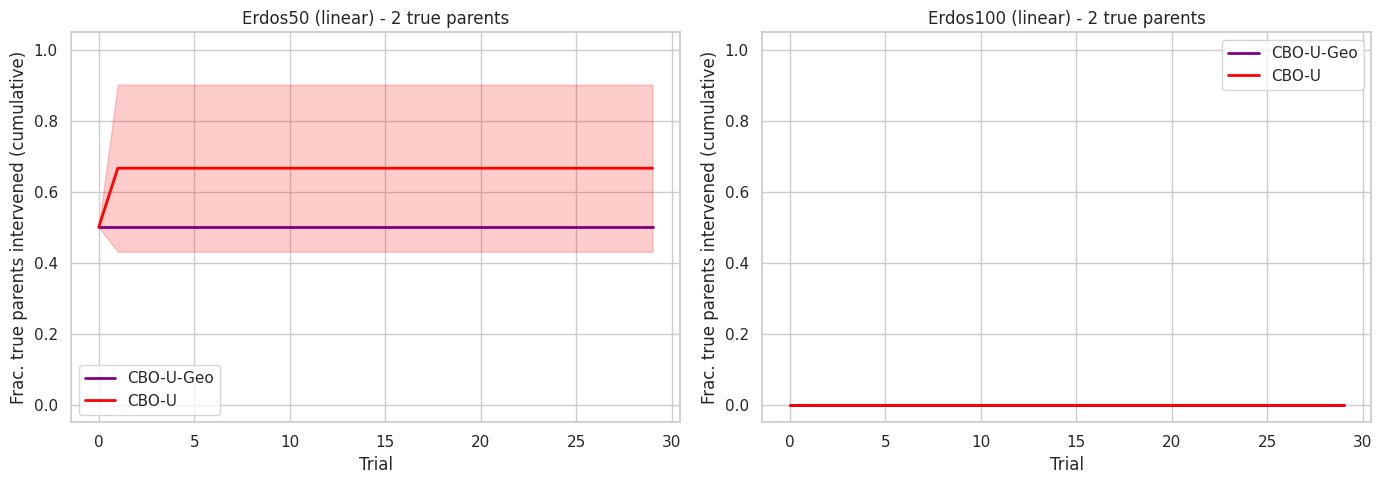

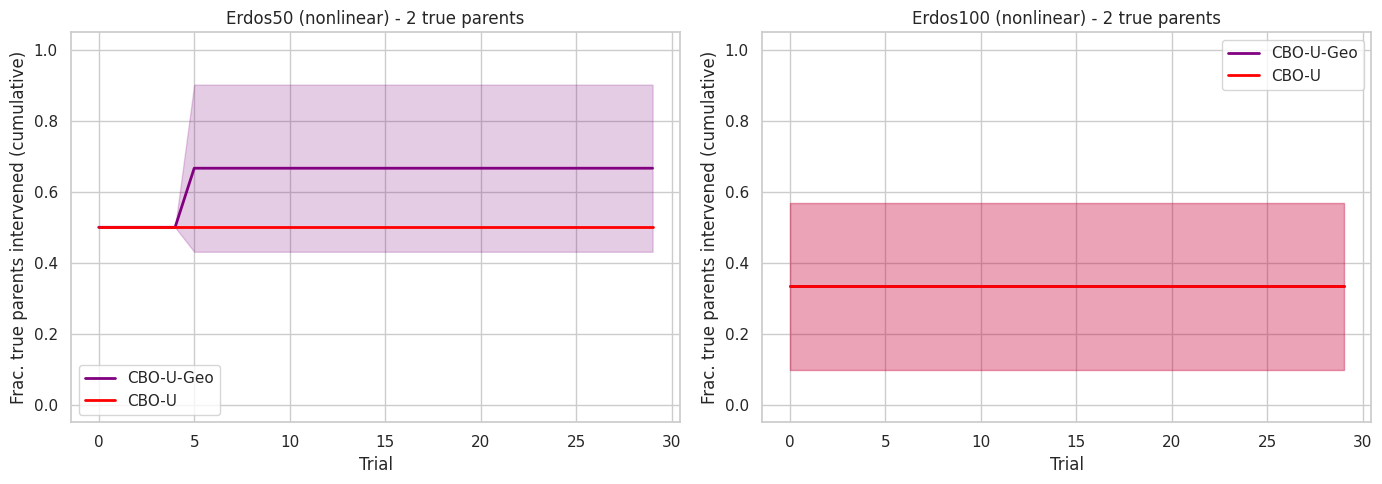

In [15]:
# Extra diagnostics. P_True_Parents / Delta_t_KL are only stored by the geometry
# runs (CBO-U-Geo alone). Coverage and Boundary compare CBO-U vs CBO-U-Geo:
# CBO-U boundary comes from a precomputed sidecar (its intervention ranges were
# reconstructed from the run seeds, since CBO-U pickles don't store them).
import pickle


def geom_series(graph, nonlinear, key):
    gbase, gregex = geom_source(graph, nonlinear)
    data = np.array([r[key] for r in load_results(gbase, gregex)], dtype=float)
    return data.mean(0), data.std(0)


def plot_geom_metric(key, ylabel, ylim=None):
    for nonlinear in [False, True]:
        kind = "nonlinear" if nonlinear else "linear"
        fig, axes = plt.subplots(1, len(GRAPHS), figsize=(14, 5))
        for ax, graph in zip(axes, GRAPHS):
            mean, std = geom_series(graph, nonlinear, key)
            x = range(len(mean))
            ax.fill_between(x, mean - std, mean + std, alpha=0.2, color="purple")
            ax.plot(x, mean, label="CBO-U-Geo", color="purple", linewidth=2)
            ax.set_title(f"{graph} ({kind})")
            ax.set_xlabel("Trial")
            ax.set_ylabel(ylabel)
            if ylim:
                ax.set_ylim(*ylim)
            ax.grid(True)
            ax.legend()
        _show(fig, f"{key}_{kind}")


def coverage(results, true_parents):
    tp = set(true_parents)
    curves = []
    for r in results:
        seen, row = set(), []
        for iv in r["Intervention_Set"]:
            seen |= set(iv) & tp
            row.append(len(seen) / len(tp))
        curves.append(row)
    return np.array(curves, dtype=float)


def plot_coverage(nonlinear=False):
    kind = "nonlinear" if nonlinear else "linear"
    fig, axes = plt.subplots(1, len(GRAPHS), figsize=(14, 5))
    for ax, graph in zip(axes, GRAPHS):
        tp = true_parents_for(graph, nonlinear)
        gbase, gregex = geom_source(graph, nonlinear)
        sources = {
            "CBO-U-Geo": (load_results(gbase, gregex), "purple"),
            "CBO-U": (load_results(f"../results/{graph}",
                                   method_regex("cbo_unknown_dr2_results", nonlinear)), "red"),
        }
        for label, (res, color) in sources.items():
            cov = coverage(res, tp)
            mean, std = cov.mean(0), cov.std(0)
            x = range(len(mean))
            ax.fill_between(x, mean - std, mean + std, alpha=0.2, color=color)
            ax.plot(x, mean, label=label, color=color, linewidth=2)
        ax.set_title(f"{graph} ({kind}) - {len(tp)} true parents")
        ax.set_xlabel("Trial")
        ax.set_ylabel("Frac. true parents intervened (cumulative)")
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True)
        ax.legend()
    _show(fig, f"coverage_{kind}")


def plot_boundary(nonlinear=False):
    kind = "nonlinear" if nonlinear else "linear"
    ns = "_nonlinear" if nonlinear else ""
    fig, axes = plt.subplots(1, len(GRAPHS), figsize=(14, 5))
    for ax, graph in zip(axes, GRAPHS):
        gmean, gstd = geom_series(graph, nonlinear, "Boundary_Percentage")
        x = range(len(gmean))
        ax.fill_between(x, gmean - gstd, gmean + gstd, alpha=0.2, color="purple")
        ax.plot(x, gmean, label="CBO-U-Geo", color="purple", linewidth=2)

        side = f"../results/{graph}/cbou_boundary_200_2{ns}.pickle"
        if os.path.exists(side):
            arr = pickle.load(open(side, "rb"))
            cmean, cstd = arr.mean(0), arr.std(0)
            x = range(len(cmean))
            ax.fill_between(x, cmean - cstd, cmean + cstd, alpha=0.2, color="red")
            ax.plot(x, cmean, label="CBO-U", color="red", linewidth=2)

        ax.set_title(f"{graph} ({kind})")
        ax.set_xlabel("Trial")
        ax.set_ylabel("Boundary fraction")
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True)
        ax.legend()
    _show(fig, f"Boundary_Percentage_{kind}")


plot_geom_metric("P_True_Parents", "P(true parents)", ylim=(-0.05, 1.05))
plot_geom_metric("Delta_t_KL", "Delta_t KL")
plot_boundary()
plot_boundary(nonlinear=True)
plot_coverage()
plot_coverage(nonlinear=True)